In [2]:
from pathlib import Path
import os, stat, glob, traceback
import numpy as np
import pandas as pd
import arviz as az
from arviz_stats.base.array import array_stats
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt

/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup

In [3]:
# Paths and helper to compile models
stan_dir = Path('../stan').resolve()
out_root = Path.cwd() / 'stan_output'
out_root.mkdir(parents=True, exist_ok=True)
models = {
    'minimal': {'file': stan_dir / 'minimal.stan', 'outdir': out_root / 'minimal'},
    'province': {'file': stan_dir / 'logistic_province.stan', 'outdir': out_root / 'province'},
    'full': {'file': stan_dir / 'logistic_full.stan', 'outdir': out_root / 'full'},
    'response': {'file': stan_dir / 'logistic_response.stan', 'outdir': out_root / 'response'},
}
for m in models.values():
    m['outdir'].mkdir(parents=True, exist_ok=True)

def compile_model(stan_path):
    print('Compiling', stan_path.name)
    mdl = CmdStanModel(stan_file=str(stan_path))
    mode = os.stat(mdl.exe_file).st_mode
    os.chmod(mdl.exe_file, mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
    return mdl

In [4]:
idata_min = az.from_netcdf(str(models['minimal']['outdir'] / 'idata.nc'))
idata_prov = az.from_netcdf(str(models['province']['outdir'] / 'idata.nc'))
idata_full = az.from_netcdf(str(models['full']['outdir'] / 'idata.nc'))
idata_response = az.from_netcdf(str(models['response']['outdir'] / 'idata.nc'))
print('Loaded saved idata for: minimal, province, full, response')

Loaded saved idata for: minimal, province, full, response


In [5]:
model_idata = {
    'minimal': idata_min,
    'province': idata_prov,
    'full': idata_full,
    'response': idata_response,
}
print('Models:', list(model_idata.keys()))

Models: ['minimal', 'province', 'full', 'response']


In [6]:
# Quick inventory
rows = []
for name, idata in model_idata.items():
    has_posterior = hasattr(idata, "posterior")
    has_log_lik = hasattr(idata, "log_likelihood")
    has_ppc = hasattr(idata, "posterior_predictive")

    n_vars = len(idata.posterior.data_vars) if has_posterior else 0
    n_draws = (
        idata.posterior.sizes.get("chain", 1) * idata.posterior.sizes.get("draw", 0)
        if has_posterior else 0
    )

    rows.append({
        "model": name,
        "has_posterior": has_posterior,
        "has_log_likelihood": has_log_lik,
        "has_posterior_predictive": has_ppc,
        "n_posterior_vars": n_vars,
        "n_draws_total": int(n_draws),
    })

pd.DataFrame(rows).set_index("model")

,has_posterior,has_log_likelihood,has_posterior_predictive,n_posterior_vars,n_draws_total
model,,,,,
minimal,True,True,True,3,4000
province,True,True,True,4,4000
full,True,True,True,6,4000
response,True,True,True,7,4000


In [7]:
loo_min = az.loo(model_idata['minimal'], pointwise=True)
print(loo_min)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2246.76    73.78
p_loo        3.17        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [8]:
loo_prov = az.loo(model_idata['province'], pointwise=True)
print(loo_prov)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2018.97    66.52
p_loo       10.57        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [9]:
loo_full = az.loo(model_idata['full'], pointwise=True)
print(loo_full)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1957.04    67.69
p_loo       20.59        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [10]:
loo_response = az.loo(model_idata['response'], pointwise=True)
print(loo_response)

Computed from 4000 posterior samples and 15203 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1947.81    67.47
p_loo       22.15        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     15203  100.0%
   (0.70, 1]   (bad)          0    0.0%
    (1, Inf)   (very bad)     0    0.0%



In [11]:
comp = az.compare({
    'minimal': loo_min,
    'province': loo_prov,
    'full': loo_full,
    'response': loo_response,
}, round_to='none')

comp

,rank,elpd,p,elpd_diff,weight,se,dse,warning
response,0,-1947.809710,22.153327,0.000000,9.198542e-01,67.471130,0.000000,False
full,1,-1957.044269,20.592059,9.234558,2.796547e-02,67.689650,4.110949,False
province,2,-2018.968597,10.566749,71.158887,6.974627e-15,66.522598,18.061649,False
minimal,3,-2246.755781,3.166470,298.946071,5.218037e-02,73.775145,30.402539,False


In [12]:
az.summary(idata_response)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-2.75,0.68,-3.8,-1.7,1471,1763,1.00,0.018,0.012
a_prov[0],0.92,0.35,0.36,1.5,1077,1695,1.00,0.011,0.0075
a_prov[1],1.53,0.33,1,2.1,1075,1547,1.00,0.01,0.0072
a_prov[2],-0.31,0.35,-0.86,0.26,1243,1900,1.00,0.01,0.0069
a_prov[3],-0.88,0.75,-2.1,0.29,3942,3058,1.00,0.012,0.0086
a_prov[4],-1.05,0.74,-2.2,0.086,4449,2799,1.00,0.011,0.0081
a_prov[5],-0.39,0.87,-1.8,0.97,4512,2863,1.00,0.013,0.0093
a_prov[6],-0.48,0.47,-1.2,0.27,2346,2814,1.00,0.0098,0.0072
a_prov[7],1.14,0.35,0.58,1.7,1102,1661,1.00,0.01,0.0076
a_prov[8],-0.24,0.44,-0.96,0.45,1793,2399,1.00,0.01,0.0075


## Posterior Comparison: Full MCMC vs Full VI

Using VI draws from: logistic_full-20260418210529.csv


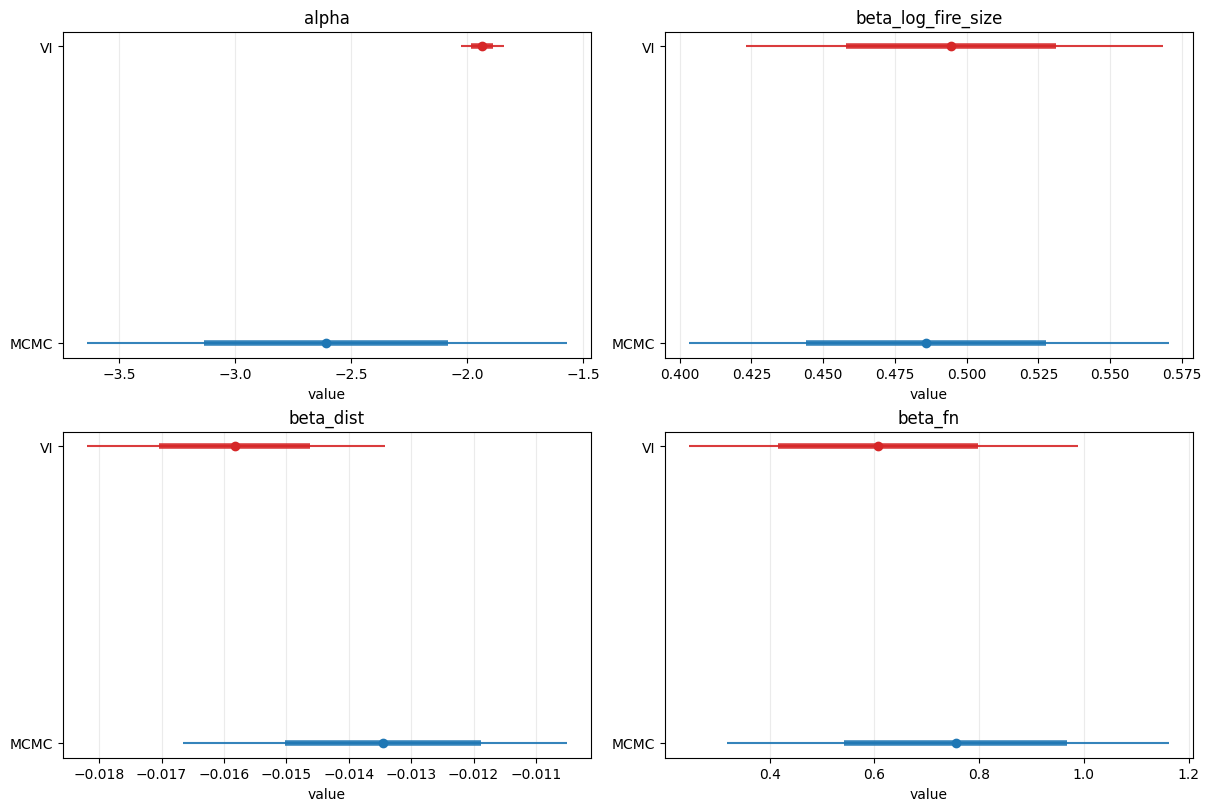

,param,method,mean,sd,q025,q50,q975,width_95
0,alpha,MCMC,-2.609226,0.525241,-3.638530,-2.615015,-1.570504,2.068027
1,alpha,VI,-1.935704,0.046894,-2.025169,-1.935719,-1.839385,0.185784
2,beta_dist,MCMC,-0.013446,0.001569,-0.016649,-0.013404,-0.010505,0.006144
3,beta_dist,VI,-0.015825,0.001209,-0.018191,-0.015836,-0.013425,0.004765
4,beta_fn,MCMC,0.755644,0.212586,0.319444,0.761994,1.162397,0.842954
5,beta_fn,VI,0.606429,0.190739,0.246613,0.602718,0.989042,0.742429
6,beta_log_fire_size,MCMC,0.485898,0.041867,0.403366,0.486086,0.570448,0.167082
7,beta_log_fire_size,VI,0.494382,0.036577,0.423306,0.494378,0.568381,0.145075


In [14]:
# Compare posterior distributions: full MCMC vs full VI
params = ['alpha', 'beta_log_fire_size', 'beta_dist', 'beta_fn']

# Load latest VI draws for logistic_full
vi_csvs = sorted((out_root / 'full_vi').glob('*.csv'))
if len(vi_csvs) == 0:
    raise FileNotFoundError('No VI CSV found in notebooks/stan_output/full_vi')

vi_csv = vi_csvs[-1]
vi_df = pd.read_csv(vi_csv, comment='#')
print('Using VI draws from:', vi_csv.name)

# Build long-format draws table for easy plotting/summaries
rows = []
for p in params:
    if p not in vi_df.columns:
        raise KeyError(f'Missing VI column: {p}')
    if p not in idata_full.posterior:
        raise KeyError(f'Missing MCMC posterior variable: {p}')

    draws_vi = vi_df[p].to_numpy(dtype=float)
    draws_mcmc = idata_full.posterior[p].values.reshape(-1).astype(float)

    rows.extend([{'param': p, 'method': 'VI', 'draw': x} for x in draws_vi])
    rows.extend([{'param': p, 'method': 'MCMC', 'draw': x} for x in draws_mcmc])

post_df = pd.DataFrame(rows)

# Numeric comparison table
summary = (
    post_df.groupby(['param', 'method'])['draw']
    .agg(
        mean='mean',
        sd='std',
        q025=lambda x: x.quantile(0.025),
        q50='median',
        q975=lambda x: x.quantile(0.975),
    )
    .reset_index()
)
summary['width_95'] = summary['q975'] - summary['q025']
summary = summary.sort_values(['param', 'method']).reset_index(drop=True)

# Interval plot: dot = mean, thick bar = +/-1 SD, thin whisker = 95% CI
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

method_order = ['MCMC', 'VI']
method_color = {'MCMC': '#1f77b4', 'VI': '#d62728'}

for ax, p in zip(axes, params):
    sub = summary[summary['param'] == p].set_index('method').loc[method_order].reset_index()
    y = np.arange(len(method_order))

    for i, row in sub.iterrows():
        m = row['mean']
        sd = row['sd']
        lo95 = row['q025']
        hi95 = row['q975']
        c = method_color[row['method']]

        # 95% CI whisker
        ax.hlines(y=i, xmin=lo95, xmax=hi95, color=c, linewidth=1.5, alpha=0.9)
        # +/- 1 SD thicker segment
        ax.hlines(y=i, xmin=m - sd, xmax=m + sd, color=c, linewidth=4, alpha=0.9)
        # Mean point
        ax.plot(m, i, 'o', color=c, markersize=6)

    ax.set_yticks(y)
    ax.set_yticklabels(method_order)
    ax.set_title(p)
    ax.set_xlabel('value')
    ax.grid(axis='x', alpha=0.25)

plt.show()

summary